In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os

import pickle
import numpy as np

import scipy.stats as stats 

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Compute TPM

In [2]:
def calculate_tpm(df, length_col="Length"):
    """
    Calculate TPM values for a gene expression dataframe.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing raw counts and a gene length column.
        Rows = genes, Columns = samples + one length column.
    length_col : str, default "Length"
        Name of the column containing gene lengths (in base pairs).

    Returns
    -------
    tpm_df : pandas.DataFrame
        DataFrame of TPM-normalized counts (same shape as count columns).
    """

    # Copy to avoid modifying original
    df = df.copy()

    # Extract lengths and convert to kilobases
    lengths_kb = df[length_col] / 1000.0

    # Identify count columns (all except length_col)
    count_cols = [c for c in df.columns if c != length_col]

    # Step 1: RPK = counts / gene_length_kb
    rpk = df[count_cols].div(lengths_kb, axis=0)

    # Step 2: per-sample scaling factor = sum(RPK)
    scaling_factors = rpk.sum(axis=0) / 1e6   # per-million scaling

    # Step 3: TPM = RPK / scaling_factor
    tpm = rpk.div(scaling_factors, axis=1)

    return tpm

In [3]:
# Import data Baseline, follow-up and HCC+/HCV+
counts_dir = '/rna_seq/output'

raw = pd.read_csv(counts_dir + '/counts.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,4:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.shape

(62703, 93)

In [4]:
tpm_raw = calculate_tpm(raw)
tpm_raw

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,...,GFB_37112,GFB_37114,GFB_37116,GFB_37118,GFB_37120,GFB_37122,GFB_37124,GFB_37126,GFB_37128,SRR3898689
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,1.005323,0.443581,2.022981,5.744143,2.582373,1.756304,2.677927,2.439642,2.300152,1.657153,...,1.703666,2.106002,1.507277,1.007839,1.231325,1.459666,1.776699,2.439026,0.511147,5.587690
ENSG00000279928,0.132902,0.000000,0.000000,0.717178,0.119251,0.000000,0.357522,0.000000,0.438385,0.684916,...,0.000000,0.639350,0.671882,0.000000,0.000000,0.000000,0.144322,0.066576,0.000000,0.078322
ENSG00000228037,1.210128,0.907712,0.725199,6.040449,2.063079,0.691148,1.546311,1.317617,1.896050,1.091380,...,1.852476,3.492932,1.376500,0.971529,0.074842,1.063152,0.459939,1.333639,0.815045,1.069731
ENSG00000142611,0.085317,0.029089,0.081341,1.412585,0.222703,0.084166,0.203433,0.230831,0.159900,0.094932,...,0.128626,0.217655,0.078422,0.068823,0.038375,0.077875,0.050535,0.306942,0.031343,0.278822
ENSG00000284616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039837,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,3.406460,1.489412,0.872621,6.810017,4.592771,3.850785,2.848848,3.472016,2.139578,2.069350,...,5.257422,7.004989,4.082249,2.155333,2.346931,2.780070,0.958333,4.747930,1.153102,6.334542
ENSG00000275987,0.000000,0.000000,0.000000,1.419415,0.000000,0.000000,0.000000,0.763730,0.000000,0.000000,...,0.000000,0.632690,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.890454
ENSG00000268674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
# Import data HCC-/HCV+

hcv_counts_dir = '/rna_seq/hcv_no_hcc/output'

os.chdir(hcv_counts_dir)

raw_2 = pd.read_csv(hcv_counts_dir + '/counts.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_2 = raw_2.iloc[:,4:]

# Change column names
raw_2.columns = raw_2.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
# Drop sample already in PRecit HCC cohort:
raw_2 = raw_2.drop('SRR3898689', axis=1)
raw_2.shape

(62703, 22)

In [6]:
tpm_raw_2 = calculate_tpm(raw_2)
tpm_raw_2

,BSSE_QGF_55032,SRR3898677,SRR3898678,SRR3898679,SRR3898680,SRR3898682,SRR3898683,SRR3898684,SRR3898685,SRR3898686,...,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898694,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,2.084028,5.737590,6.062801,4.914266,6.798261,2.360368,4.522953,5.428488,5.430060,6.687556,...,5.454285,3.842653,4.393489,6.157138,4.779480,5.232227,5.219307,6.590090,6.680956,7.423872
ENSG00000279928,0.906499,0.000000,0.000000,1.050543,0.000000,0.000000,0.094703,0.000000,0.407344,0.678018,...,0.272395,0.000000,0.333449,0.121915,0.699430,0.432307,0.122184,0.855472,0.000000,0.654995
ENSG00000228037,0.412703,0.645306,0.886176,0.441491,2.623772,0.610116,0.776077,1.211831,1.947247,1.234730,...,1.570842,1.743816,0.607239,0.444036,0.636862,1.653262,0.778779,0.876312,0.783355,1.192802
ENSG00000142611,0.088172,0.103400,0.154904,0.080174,0.935426,0.149900,0.160278,0.077670,0.095090,0.207737,...,0.095382,0.080721,0.071353,0.163644,0.163274,0.282568,0.206789,0.162257,0.143451,0.197498
ENSG00000284616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,3.431053,2.164751,2.702526,1.738603,3.097351,1.230988,2.565707,1.567174,2.921260,2.836397,...,1.893185,2.161893,3.395087,2.315306,3.489935,2.870629,4.072910,4.146807,4.309027,4.523311
ENSG00000275987,0.000000,0.000000,0.000000,0.000000,0.000000,0.884103,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.342243,0.000000,0.000000,0.000000,0.000000
ENSG00000268674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
# Concat input raw data

tpm_concat = pd.concat([tpm_raw, tpm_raw_2], axis=1, join='outer')
tpm_concat.shape

(62703, 113)

In [8]:
tpm_concat.head()

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,...,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898694,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,1.005323,0.443581,2.022981,5.744143,2.582373,1.756304,2.677927,2.439642,2.300152,1.657153,...,5.454285,3.842653,4.393489,6.157138,4.779480,5.232227,5.219307,6.590090,6.680956,7.423872
ENSG00000279928,0.132902,0.000000,0.000000,0.717178,0.119251,0.000000,0.357522,0.000000,0.438385,0.684916,...,0.272395,0.000000,0.333449,0.121915,0.699430,0.432307,0.122184,0.855472,0.000000,0.654995
ENSG00000228037,1.210128,0.907712,0.725199,6.040449,2.063079,0.691148,1.546311,1.317617,1.896050,1.091380,...,1.570842,1.743816,0.607239,0.444036,0.636862,1.653262,0.778779,0.876312,0.783355,1.192802
ENSG00000142611,0.085317,0.029089,0.081341,1.412585,0.222703,0.084166,0.203433,0.230831,0.159900,0.094932,...,0.095382,0.080721,0.071353,0.163644,0.163274,0.282568,0.206789,0.162257,0.143451,0.197498
ENSG00000284616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039837,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# Import metadata
meta = pd.read_csv('Sample_mapping_follow_up.csv', index_col='Code')
meta = meta.reset_index(names='Code')
meta.index = meta.Biopsy_ID
meta = meta.drop('Biopsy_ID', axis=1)
meta.Code = meta.Code.str.replace('-', '_')
meta.head()

# "Elastic Net" genes

In [10]:
revised_dir = "/hcc_predict_revised"
os.chdir(revised_dir)
elas = pd.read_csv('elasticnet_parallel_bootstrap_results_22122025.csv', index_col=0)
elas = elas.iloc[:100]
elas.head()

,Gene.1,Value
Gene,,
UBIAD1,UBIAD1,0.846
RPS4Y1,RPS4Y1,0.832
LPAR3,LPAR3,0.800
GAL3ST1,GAL3ST1,0.788
PSD2,PSD2,0.722


In [11]:
elas.loc['PINX1',:]

Gene.1    PINX1
Value     0.426
Name: PINX1, dtype: object

In [12]:
# Get anootations from ensemble
with open(os.getenv("HOME") + '/ensemble_mappings_gene.pkl', 'rb') as f:
    ensembl_dict = pickle.load(f)

df_input = tpm_concat.copy()

df_input['Gene_name'] = df_input.index.map(ensembl_dict)
#print(df_input[df_input.Gene_name == ''])
df_input['Gene_name'] = np.where(df_input.Gene_name == '', df_input.index, df_input.Gene_name)
df_input.index = df_input.Gene_name
df_input  = df_input.loc[elas.index,]
df_input = df_input.drop('Gene_name', axis=1)

In [13]:
df_input.head()

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,...,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898694,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Gene,,,,,,,,,,,,,,,,,,,,,
UBIAD1,5.149487,6.335345,6.109483,18.190820,10.696735,4.573093,9.779000,8.221273,6.799272,8.456159,...,6.599030,5.647590,6.883195,7.153946,6.836672,6.525878,8.154911,8.334550,7.996379,8.863020
RPS4Y1,50.455893,0.065798,69.179102,108.209515,0.125934,0.040080,41.153949,43.578226,40.190190,27.801922,...,67.624428,0.028090,39.967521,60.833292,0.000000,57.044062,0.000000,0.000000,63.921742,0.028821
LPAR3,0.171389,0.000000,0.032097,0.317923,0.134562,0.000000,0.014408,0.186613,0.053000,0.082806,...,0.014637,0.017151,0.161255,0.019653,0.064427,0.027875,0.039392,0.017238,0.000000,0.228767
GAL3ST1,0.416096,0.596685,0.183350,3.269011,3.140595,0.573151,1.399188,1.101547,2.018412,1.135257,...,0.953163,0.862173,1.924199,1.549247,1.232922,2.340742,2.497774,3.111624,2.240833,1.125872
PSD2,0.016715,0.062691,0.025043,0.202953,0.044995,0.019094,0.044966,0.024267,0.068921,0.010768,...,0.171299,0.066909,0.139795,0.061334,0.113103,0.152242,0.092204,0.147943,0.061831,0.151030


In [14]:
df_input.loc['PINX1', :]

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,...,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898694,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Gene,,,,,,,,,,,,,,,,,,,,,
PINX1,2.242362,1.671853,3.035673,5.503523,3.369561,2.54596,3.052453,2.274847,1.91598,1.68817,...,1.864217,1.059792,2.146487,1.80916,2.33583,1.722443,2.136049,1.804225,1.698893,2.174751
PINX1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
df_input = df_input.loc[~(df_input==0).all(axis=1)]
df_input = df_input[df_input.index.isin(elas.index)]

In [16]:
df_input.shape

(100, 113)

In [17]:
meta_baseline = meta[(meta['Sample description'] == 'HCC Predict cohort') & (meta['Baseline biopsy'] != 'follow_up')].copy()
baseline_samples = meta_baseline.Code.tolist()

In [19]:
meta_baseline.index = meta_baseline.Code

In [20]:
df_input_baseline = df_input.loc[:,baseline_samples].copy()

# Import HCC- HCV+ samples (Neg Ctrl)

In [22]:
meta['Sample description'].unique()

array(['Non-Tumor-Liver', 'Liver early resection', 'HCC Predict cohort',
       'Liver chronic HCV'], dtype=object)

In [23]:
meta_hcv = meta[meta['Sample description'] == 'Liver chronic HCV'].copy()

# Missing sample
meta_hcv = meta_hcv[meta_hcv.Code != 'SRR3898681']

In [24]:
elas.index

Index(['UBIAD1', 'RPS4Y1', 'LPAR3', 'GAL3ST1', 'PSD2', 'UQCRHL', 'SLC8A3',
       'CLEC9A', 'NPFF', 'C11orf16', 'PLAAT2', 'SESN1', 'NQO1', 'RRM2B',
       'KBTBD3', 'CDKN2A', 'GPR160', 'VARS2', 'CHIC2', 'STK38L', 'PIGW',
       'PINX1', 'KLRB1', 'BEX2', 'VWDE', 'TXNDC12', 'EXOC3', 'TTPAL',
       'ENSG00000278384', 'CCDC170', 'BRINP1', 'LRRC17', 'SLC30A2', 'TRIM15',
       'LILRB3', 'PRICKLE4', 'MYO19', 'SERPINI1', 'ZFP14', 'MUC13', 'AP5S1',
       'KCNK5', 'WDR6', 'IGFBPL1', 'ATXN3', 'RAB25', 'FAM3B', 'OLR1', 'ODC1',
       'ARPC3', 'TVP23B', 'TMSB10', 'ZNF93', 'STX1B', 'VSIG2', 'ZNF626',
       'POLR2D', 'TRAPPC2B', 'TM2D1', 'EMCN', 'DPPA4', 'PRR15', 'SELENOS',
       'EGFLAM', 'GDPD1', 'XPR1', 'BSN', 'ZNF880', 'CTSG', 'TBC1D8', 'TSPAN8',
       'PRB1', 'AGGF1', 'SLC22A25', 'COG7', 'PDCD11', 'COLEC11', 'PLGRKT',
       'MLXIPL', 'HOXD8', 'GIMAP2', 'DLGAP5', 'WDR41', 'NUTM2B', 'DRAM2',
       'S100A10', 'ATXN7L2', 'GEMIN4', 'THTPA', 'ZSWIM1', 'PRSS48', 'TUSC3',
       'COMMD2', 'RGCC'

In [25]:
df_input.head()

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,...,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898694,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Gene,,,,,,,,,,,,,,,,,,,,,
UBIAD1,5.149487,6.335345,6.109483,18.190820,10.696735,4.573093,9.779000,8.221273,6.799272,8.456159,...,6.599030,5.647590,6.883195,7.153946,6.836672,6.525878,8.154911,8.334550,7.996379,8.863020
RPS4Y1,50.455893,0.065798,69.179102,108.209515,0.125934,0.040080,41.153949,43.578226,40.190190,27.801922,...,67.624428,0.028090,39.967521,60.833292,0.000000,57.044062,0.000000,0.000000,63.921742,0.028821
LPAR3,0.171389,0.000000,0.032097,0.317923,0.134562,0.000000,0.014408,0.186613,0.053000,0.082806,...,0.014637,0.017151,0.161255,0.019653,0.064427,0.027875,0.039392,0.017238,0.000000,0.228767
GAL3ST1,0.416096,0.596685,0.183350,3.269011,3.140595,0.573151,1.399188,1.101547,2.018412,1.135257,...,0.953163,0.862173,1.924199,1.549247,1.232922,2.340742,2.497774,3.111624,2.240833,1.125872
PSD2,0.016715,0.062691,0.025043,0.202953,0.044995,0.019094,0.044966,0.024267,0.068921,0.010768,...,0.171299,0.066909,0.139795,0.061334,0.113103,0.152242,0.092204,0.147943,0.061831,0.151030


In [26]:
hcv_subset = df_input.copy()
hcv_subset = hcv_subset.loc[:,meta_hcv.Code]
hcv_subset.head()

,SRR3898677,SRR3898678,SRR3898679,SRR3898680,SRR3898682,SRR3898683,SRR3898684,SRR3898685,SRR3898686,SRR3898687,SRR3898688,SRR3898690,SRR3898691,SRR3898692,SRR3898693,SRR3898719,SRR3898720,SRR3898721,SRR3898722
Gene,,,,,,,,,,,,,,,,,,,
UBIAD1,5.806779,6.499618,5.583578,6.050397,4.602198,6.257067,5.593915,4.823905,6.029899,5.975217,6.599030,5.647590,6.883195,7.153946,6.836672,8.154911,8.334550,7.996379,8.863020
RPS4Y1,55.695154,0.023359,44.931503,0.023774,0.000000,0.000000,54.204581,0.080658,49.614032,95.944675,67.624428,0.028090,39.967521,60.833292,0.000000,0.000000,0.000000,63.921742,0.028821
LPAR3,0.000000,0.085574,0.000000,0.145157,0.090010,0.061064,0.014303,0.000000,0.018216,0.064428,0.014637,0.017151,0.161255,0.019653,0.064427,0.039392,0.017238,0.000000,0.228767
GAL3ST1,1.305206,1.270971,1.458514,1.923746,1.460269,1.273206,1.960857,2.194327,1.259098,2.852340,0.953163,0.862173,1.924199,1.549247,1.232922,2.497774,3.111624,2.240833,1.125872
PSD2,0.029712,0.066767,0.040655,0.079279,0.070229,0.142931,0.078115,0.076849,0.028425,0.075404,0.171299,0.066909,0.139795,0.061334,0.113103,0.092204,0.147943,0.061831,0.151030


In [27]:
hcv_subset.shape

(100, 19)

In [28]:
meta_hcv.Code

Biopsy_ID
A584    SRR3898677
A609    SRR3898678
A764    SRR3898679
A720    SRR3898680
A991    SRR3898682
C552    SRR3898683
A748    SRR3898684
A727    SRR3898685
B254    SRR3898686
A616    SRR3898687
B136    SRR3898688
A707    SRR3898690
A972    SRR3898691
B215    SRR3898692
B320    SRR3898693
C186    SRR3898719
C071    SRR3898720
C106    SRR3898721
B929    SRR3898722
Name: Code, dtype: object

# Import HCC+ HCV+ (Pos Ctrl)

In [29]:
# Same raw data as baseline

In [30]:
meta['Baseline biopsy'].unique()

array(['no', 'CHC_noHCC', 'CHC_HCC', 'follow_up', 'HCV_noHCC'],
      dtype=object)

In [31]:
# metadata for Deseq
meta_hcc_hcv = meta.copy()
meta_hcc_hcv.index = meta_hcc_hcv.Code
meta_hcc_hcv = meta_hcc_hcv.drop(['Code', 'Biopsy_ID.1', 'Metavir Staging (F)', 'Patho_Report', 'Sample description'], axis=1)
meta_hcc_hcv = meta_hcc_hcv[(meta_hcc_hcv['Baseline biopsy'] == 'no') & (meta_hcc_hcv['Cured HCV'] == 'no')]
meta_hcc_hcv.head()

,Gender,Cured HCV,HCC Status,Patient_ID,Baseline biopsy
Code,,,,,
BSSE_QGF_158634,m,no,yes,3729049,no
BSSE_QGF_34364,m,no,yes,2158853,no
BSSE_QGF_34368,m,no,yes,3433655,no
BSSE_QGF_34386,f,no,yes,2332714,no
BSSE_QGF_34407,m,no,yes,3403106,no


In [32]:
hcc_hcv_subset = df_input.copy()
hcc_hcv_subset = hcc_hcv_subset.loc[:,meta_hcc_hcv.index]
hcc_hcv_subset.head()

Code,BSSE_QGF_158634,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34386,BSSE_QGF_34407,BSSE_QGF_34411,BSSE_QGF_34425,BSSE_QGF_34436,BSSE_QGF_34444,BSSE_QGF_34448,...,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55023,BSSE_QGF_55032,BSSE_QGF_55705,BSSE_QGF_55718,BSSE_QGF_55724,BSSE_QGF_79903
Gene,,,,,,,,,,,,,,,,,,,,,
UBIAD1,18.190820,5.118061,7.192687,7.573727,8.733075,9.427660,10.509080,10.374644,9.694454,15.552561,...,6.044073,9.422431,6.320435,6.971900,7.781654,4.652709,7.904701,7.512139,6.993774,11.515856
RPS4Y1,108.209515,56.001914,55.011036,0.038565,37.281335,0.000000,71.574887,51.174326,44.335724,93.235249,...,60.679786,81.761474,71.047802,55.227521,51.425744,53.489325,62.846632,71.361600,60.384422,81.601579
LPAR3,0.317923,0.168718,0.163051,0.470938,0.135173,0.078294,0.000000,0.000000,2.745612,0.040779,...,1.368590,0.806634,0.228166,0.125449,0.250594,0.000000,0.090787,0.138890,0.166679,0.163664
GAL3ST1,3.269011,1.349306,1.001274,2.448089,1.945861,0.596331,5.761036,1.353629,3.733085,5.777080,...,1.489140,3.140162,0.651694,0.229318,1.002050,0.584318,0.345744,0.521377,0.418943,1.709571
PSD2,0.202953,0.000000,0.000000,0.073488,0.063280,0.000000,0.000000,0.042996,0.017704,0.159084,...,0.025424,0.046619,0.133517,0.000000,0.117312,0.152017,0.070835,0.030962,0.052019,0.072969


In [33]:
hcv_subset.shape

(100, 19)

# Linear Regression Models

In [35]:
df_input_baseline.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,...,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225217,BSSE_QGF_225218,SRR3898689
Gene,,,,,,,,,,,,,,,,,,,,,
UBIAD1,9.779000,8.221273,6.799272,8.456159,7.281019,8.351689,7.580813,8.417825,8.278998,9.376655,...,7.642483,7.708838,8.822873,8.434331,7.586381,8.347033,6.368768,8.453090,8.891978,8.534001
RPS4Y1,41.153949,43.578226,40.190190,27.801922,65.156659,46.478823,52.643147,40.843449,0.022565,0.000000,...,0.099545,41.423339,42.570783,45.981430,0.000000,48.105728,58.155548,49.311370,85.063925,53.452196
LPAR3,0.014408,0.186613,0.053000,0.082806,0.359029,0.338650,0.139903,0.028714,0.840421,0.316999,...,0.085092,0.111665,0.038197,1.243641,0.216120,0.377323,0.142560,0.140787,0.206172,0.037876
GAL3ST1,1.399188,1.101547,2.018412,1.135257,2.114036,0.638391,1.278699,0.410067,1.463867,1.524918,...,0.694405,0.972767,1.723743,2.184549,0.566452,1.670463,1.804134,1.999109,2.728438,1.428013
PSD2,0.044966,0.024267,0.068921,0.010768,0.064644,0.118901,0.013645,0.100816,0.064497,0.039052,...,0.028453,0.021781,0.044703,0.121291,0.000000,0.027600,0.000000,0.078462,0.067025,0.128059


In [36]:
model_input = df_input_baseline.T.copy()

In [37]:
model_input.shape

(48, 100)

In [39]:
meta_baseline.index = meta_baseline.Code

In [40]:
model_input['group'] = meta_baseline['Baseline biopsy']
model_input['group'] = np.where(model_input['group'] == 'CHC_noHCC', 0, 1)
model_input.head()

Gene,UBIAD1,RPS4Y1,LPAR3,GAL3ST1,PSD2,UQCRHL,SLC8A3,CLEC9A,NPFF,C11orf16,...,TUSC3,COMMD2,RGCC,RGS2,CPNE1,SLPI,S100A13,TGFA,EMP1,group
BSSE_QGF_225167,9.779000,41.153949,0.014408,1.399188,0.044966,1.822870,0.189174,0.838118,0.228120,0.332220,...,4.849280,9.190215,10.288304,7.246756,16.478664,278.412789,8.529466,4.403585,4.208175,0
BSSE_QGF_225168,8.221273,43.578226,0.186613,1.101547,0.024267,1.790911,0.133994,1.193311,1.149014,0.316390,...,2.638178,8.537546,5.605628,8.480033,15.880836,245.418646,10.347572,5.345642,3.236272,0
BSSE_QGF_225169,6.799272,40.190190,0.053000,2.018412,0.068921,1.547418,0.166722,0.371714,1.025624,0.215661,...,1.805487,6.457557,2.729265,5.116065,18.751343,124.310808,8.739013,1.931140,1.252109,0
BSSE_QGF_225170,8.456159,27.801922,0.082806,1.135257,0.010768,1.298356,0.067951,0.427024,0.218509,0.149752,...,2.059203,7.108193,2.890114,3.926460,12.159494,202.979708,4.778728,2.312480,3.887575,0
BSSE_QGF_225171,7.281019,65.156659,0.359029,2.114036,0.064644,1.747054,0.107650,0.615263,0.000000,0.037459,...,2.831831,8.498751,8.106382,9.120157,9.527398,164.835179,11.854431,4.836119,7.586311,1


In [41]:
from sklearn.metrics import roc_auc_score



def logreg_stability_over_k_cv(
    X,
    y,
    ranked_genes,
    k_values,
    n_splits=5,
    n_repeats=100,
    top_m_for_stability=20,
    random_state=42,
    logreg_params=None,
    use_abs_for_importance=True,
):
    """
    Stability analysis over different k (top-k genes) using:
    - RepeatedStratifiedKFold
    - LogisticRegression (linear model, prob. output, AUC on folds)
    - Feature "importance" = |coefficient| (or raw coefficient if use_abs_for_importance=False)

    IMPORTANT:
    - For meaningful coefficients, X should be scaled (e.g. StandardScaler) BEFORE calling this.
    - Handles class imbalance with per-fold class_weight.

    Parameters
    ----------
    X : array-like or DataFrame, shape (n_samples, n_features)
    y : array-like, shape (n_samples,)
        Binary labels encoded as 0/1.
    ranked_genes : list of str
        Global ranking of genes (feature names), e.g. from some prior method.
    k_values : iterable of int
        Values of k (top-k genes) to evaluate.
    n_splits : int
        Number of folds per repeat.
    n_repeats : int
        Number of repeats for the CV.
    top_m_for_stability : int
        Number of top features (by importance) per model used to compute Jaccard stability.
    random_state : int
        Base random seed.
    logreg_params : dict or None
        Extra parameters passed to LogisticRegression.
    use_abs_for_importance : bool
        If True, rank features by |coef|; otherwise by signed coef.

    Returns
    -------
    results : dict
        keys = k
        values = {
            "auc_mean": float,
            "auc_std": float,
            "jaccard_mean": float,
            "jaccard_std": float,
            "importances_mean": pd.Series (index = genes_k),
            "importances_std": pd.Series (index = genes_k),
            "top_m_used": int,
            "n_models_effective": int,
        }
    """
    

    # Ensure DataFrame for column selection
    X = pd.DataFrame(X)
    y = np.asarray(y)

    assert set(ranked_genes).issubset(set(X.columns)), \
        "All ranked_genes must be columns in X"

    if len(np.unique(y)) != 2:
        raise ValueError("y must be binary (contain exactly two classes).")

    # Default logistic regression hyperparameters; suitable for small data
    default_logreg_params = dict(
        penalty="l2",
        C=1.0,
        solver="liblinear",   # robust for small n, supports class_weight
        max_iter=1000,
        fit_intercept=True,
    )
    if logreg_params is not None:
        default_logreg_params.update(logreg_params)

    results = {}

    for k in k_values:
        genes_k = ranked_genes[:k]
        X_k = X[genes_k].values

        rskf = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state,
        )

        auc_list = []
        importances_list = []  # each element is a pd.Series indexed by genes_k

        # CV loop
        for fold_id, (train_idx, test_idx) in enumerate(
            tqdm(rskf.split(X_k, y), desc=f"k={k}", leave=False)
        ):
            X_train, X_test = X_k[train_idx], X_k[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Ensure both classes are present in train and test
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            # scale inputs
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # Handle imbalance via per-fold class_weight
            n_pos = np.sum(y_train == 1)
            n_neg = np.sum(y_train == 0)
            if n_pos == 0 or n_neg == 0:
                continue

            scale_pos_weight = n_neg / n_pos
            class_weight = {0: 1.0, 1: scale_pos_weight}

            params = default_logreg_params.copy()
            params["class_weight"] = class_weight
            params["random_state"] = random_state + fold_id

            model = LogisticRegression(**params)
            model.fit(X_train, y_train)

            # AUC on test fold
            proba_test = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, proba_test)
            auc_list.append(auc)

            # Coefficient-based importances
            coefs = model.coef_[0]   # shape (k,)
            if use_abs_for_importance:
                imp_vals = np.abs(coefs)
            else:
                imp_vals = coefs

            imp_series = pd.Series(imp_vals, index=genes_k)
            importances_list.append(imp_series)

        if len(auc_list) == 0:
            # Nothing usable for this k
            continue

        # Stack importance vectors into DataFrame: rows = models, cols = genes_k
        imp_df = pd.DataFrame(importances_list)

        imp_mean = imp_df.mean(axis=0)
        imp_std = imp_df.std(axis=0)

        # --- Top-m stability (Jaccard) ---
        m = min(top_m_for_stability, k)

        top_sets = []
        for imp in importances_list:
            # sort descending by importance
            top_feats = imp.sort_values(ascending=False).index[:m]
            top_sets.append(set(top_feats))

        jaccards = []
        for i in range(len(top_sets)):
            for j in range(i + 1, len(top_sets)):
                s1, s2 = top_sets[i], top_sets[j]
                inter = len(s1 & s2)
                union = len(s1 | s2)
                if union > 0:
                    jaccards.append(inter / union)

        jaccards = np.array(jaccards) if len(jaccards) > 0 else np.array([np.nan])

        results[k] = {
            "auc_mean": float(np.mean(auc_list)),
            "auc_std": float(np.std(auc_list)),
            "jaccard_mean": float(np.nanmean(jaccards)),
            "jaccard_std": float(np.nanstd(jaccards)),
            "importances_mean": imp_mean,
            "importances_std": imp_std,
            "top_m_used": m,
            "n_models_effective": len(auc_list),
        }

    return results

In [42]:

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss


def fit_logreg_repeated_cv(
    X,
    y,
    n_splits=5,
    n_repeats=100,        # ~500 models if 5x100
    random_state=42,
    logreg_params=None,
):
    """
    Repeated stratified CV logistic regression with:
    - No resampling / no altered class ratio
    - Class imbalance handled via class_weight
    - For each fold: train on train_idx, predict on test_idx
    - Aggregate all out-of-fold probabilities per sample

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    y : array-like, shape (n_samples,)
        Binary labels encoded as 0/1.
    n_splits : int
        Number of CV folds per repeat.
    n_repeats : int
        Number of repeated CV rounds.
    random_state : int
        Base random seed.
    logreg_params : dict or None
        Extra parameters passed to LogisticRegression.
        If None, sensible defaults are used.

    Returns
    -------
    models : list of LogisticRegression
        One fitted model per fold.
    fold_indices : list of (train_idx, test_idx)
        Original indices for each fold.
    per_sample_probas : list of list
        For each i, list of out-of-fold probabilities across folds.
    mean_proba : np.ndarray, shape (n_samples,)
        Mean out-of-fold probability per sample (NaN if never in test).
    proba_std : np.ndarray, shape (n_samples,)
        Std of out-of-fold probability per sample (NaN if <2 preds).
    """

    

    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = len(y)

    if len(np.unique(y)) != 2:
        raise ValueError("y must be binary (contain exactly two classes).")

    # Default logistic regression hyperparameters; conservative for small data
    default_logreg_params = dict(
        penalty="l2",
        C=1.0,
        solver="liblinear",   # good for small datasets, supports class_weight
        max_iter=1000,
        fit_intercept=True,
        n_jobs=None,          # liblinear ignores n_jobs; kept for clarity
    )

    if logreg_params is not None:
        default_logreg_params.update(logreg_params)

    rskf = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    models = []
    fold_indices = []
    all_coefs = []
    per_sample_probas = [[] for _ in range(n_samples)]

    eps = 1e-15  # to avoid log(0)
    fold_log_losses = []
    fold_brier_losses = []

    scalers = []

    for fold_id, (train_idx, test_idx) in enumerate(tqdm(rskf.split(X, y))):
        # Handle class imbalance via class_weight on the TRAIN FOLD only
        y_train = y[train_idx]
        n_pos = np.sum(y_train == 1)
        n_neg = np.sum(y_train == 0)

        X_train, X_test = X[train_idx], X[test_idx]

        if n_pos == 0 or n_neg == 0:
            # Degenerate fold, skip
            continue

        # scale inputs
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        scalers.append(scaler)

        # Similar spirit to scale_pos_weight: upweight the minority class
        scale_pos_weight = n_neg / n_pos

        params = default_logreg_params.copy()
        params["class_weight"] = {0: 1.0, 1: scale_pos_weight}
        # Add fold-specific random_state for reproducible shuffling if used internally
        params["random_state"] = random_state + fold_id

        model = LogisticRegression(**params)
        model.fit(X_train, y_train)
        all_coefs.append(model.coef_[0].copy())

        # Out-of-fold predictions (probability for class 1)
        proba_test = model.predict_proba(X_test)[:, 1]
        # for logloss
        proba_test_clip = np.clip(proba_test, eps, 1 - eps)

        for i, p in zip(test_idx, proba_test):
            per_sample_probas[i].append(p)

        models.append(model)
        fold_indices.append((train_idx, test_idx))

        ll = log_loss(y[test_idx], proba_test_clip, labels=[0, 1])
        bs = brier_score_loss(y[test_idx], proba_test)  # quadratic loss on probabilities
        
        fold_log_losses.append(ll)
        fold_brier_losses.append(bs)

    # Aggregate per sample
    mean_proba = np.array([
        np.mean(vals) if len(vals) > 0 else np.nan
        for vals in per_sample_probas
    ])

    proba_std = np.array([
        np.std(vals, ddof=1) if len(vals) > 1 else np.nan
        for vals in per_sample_probas
    ])

    return models, fold_indices, per_sample_probas, mean_proba, proba_std, all_coefs, fold_log_losses, fold_brier_losses, scalers


# Optimnal number of features?

In [43]:
# ranked_genes = list of genes ordered by elastic-net selection frequency
k_values = list(range(5, 101, 5))  # 5, 10, 15, ..., 100

X = model_input.iloc[:,:-1]
y = model_input.group

results = logreg_stability_over_k_cv(
    X=X,            # your gene expression DataFrame
    y=y,             # 0/1
    ranked_genes=elas.index.tolist(),
    k_values=k_values
)

# Turn results into a DataFrame for plotting
res_df = pd.DataFrame.from_dict(results, orient="index")
res_df.index.name = "k"
res_df.reset_index(inplace=True)

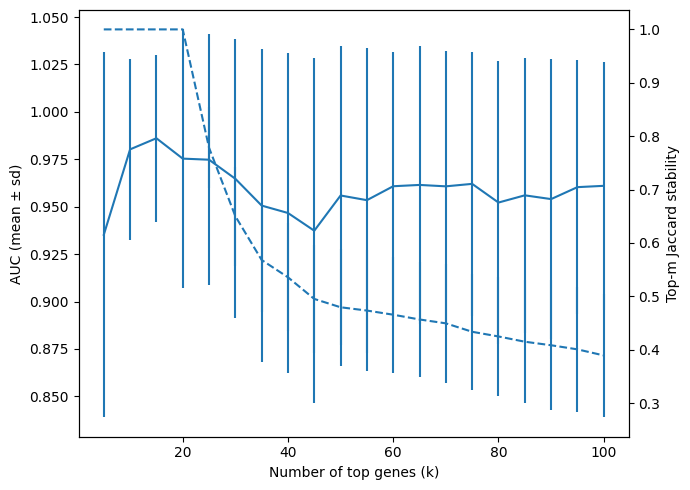

In [44]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.errorbar(res_df["k"], res_df["auc_mean"], yerr=res_df["auc_std"])
ax1.set_xlabel("Number of top genes (k)")
ax1.set_ylabel("AUC (mean ± sd)")

ax2 = ax1.twinx()
ax2.errorbar(res_df["k"], res_df["jaccard_mean"], yerr=res_df["jaccard_std"], linestyle="--")
ax2.set_ylabel("Top-m Jaccard stability")

plt.tight_layout()
plt.savefig(f'lr_stability_over_k_resampled_5-100_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [45]:
# ranked_genes = list of genes ordered by elastic-net selection frequency
k_values = list(range(10, 30, 1))  # 5, 10, 15, ..., 100

X = model_input.iloc[:,:-1]
y = model_input.group

results = logreg_stability_over_k_cv(
    X=X,            # your gene expression DataFrame
    y=y,             # 0/1
    ranked_genes=elas.index.tolist(),
    k_values=k_values
)

# Turn results into a DataFrame for plotting
res_df = pd.DataFrame.from_dict(results, orient="index")
res_df.index.name = "k"
res_df.reset_index(inplace=True)

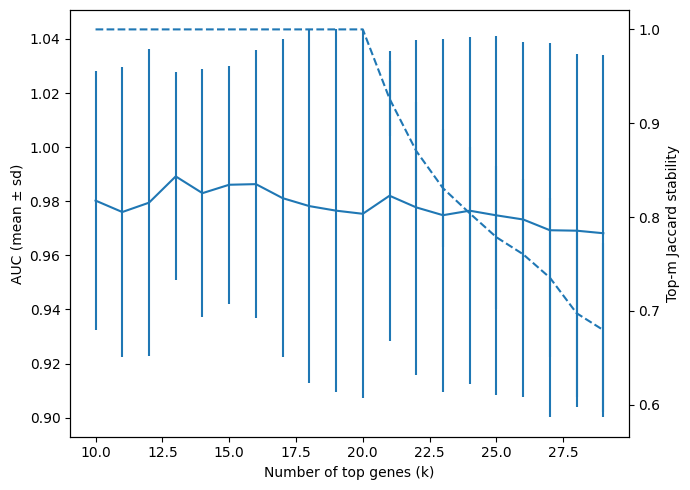

In [46]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.errorbar(res_df["k"], res_df["auc_mean"], yerr=res_df["auc_std"])
ax1.set_xlabel("Number of top genes (k)")
ax1.set_ylabel("AUC (mean ± sd)")

ax2 = ax1.twinx()
ax2.errorbar(res_df["k"], res_df["jaccard_mean"], yerr=res_df["jaccard_std"], linestyle="--")
ax2.set_ylabel("Top-m Jaccard stability")

plt.tight_layout()
plt.savefig(f'lr_stability_over_k_resampled_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [47]:
model_input.iloc[:,0:20].columns

Index(['UBIAD1', 'RPS4Y1', 'LPAR3', 'GAL3ST1', 'PSD2', 'UQCRHL', 'SLC8A3',
       'CLEC9A', 'NPFF', 'C11orf16', 'PLAAT2', 'SESN1', 'NQO1', 'RRM2B',
       'KBTBD3', 'CDKN2A', 'GPR160', 'VARS2', 'CHIC2', 'STK38L'],
      dtype='object', name='Gene')

In [48]:
# without CHIC2

top20_features = ['UBIAD1', 'RPS4Y1', 'LPAR3', 'GAL3ST1', 'PSD2', 'UQCRHL', 'SLC8A3',
       'CLEC9A', 'NPFF', 'C11orf16', 'PLAAT2', 'SESN1', 'NQO1', 'RRM2B',
       'KBTBD3', 'CDKN2A', 'GPR160', 'VARS2', 'STK38L']

In [49]:
# Top 20 features
X = model_input.loc[:,top20_features]
X_previous = model_input.iloc[:,0:20]
y = model_input.group

In [50]:
X.shape

(48, 19)

In [51]:
y.shape

(48,)

In [52]:
models, fold_indices, per_sample_probas, mean_proba, proba_std, all_coefs, fold_log_losses, fold_brier_losses, scalers = fit_logreg_repeated_cv(X, y)

500it [00:00, 526.59it/s]


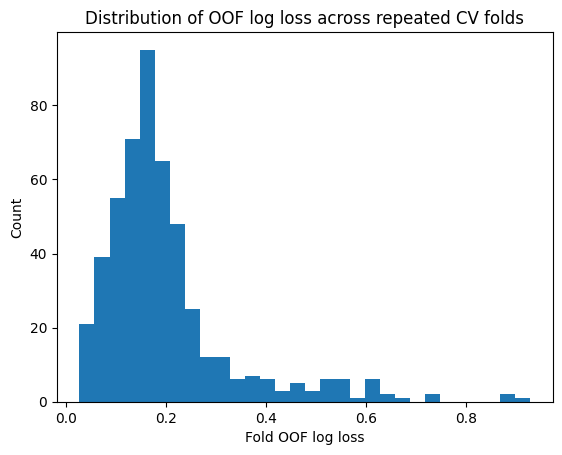

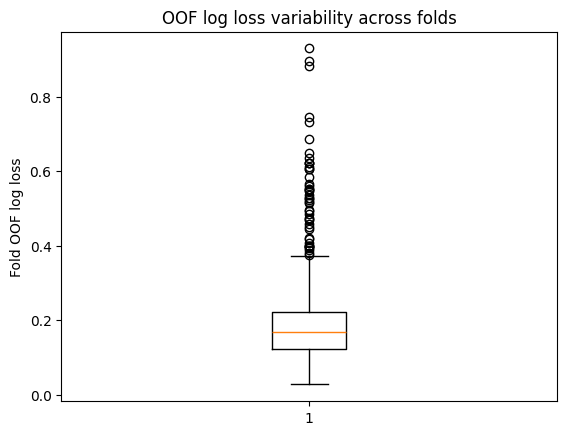

In [53]:
plt.figure()
plt.hist(fold_log_losses, bins=30)
plt.xlabel("Fold OOF log loss")
plt.ylabel("Count")
plt.title("Distribution of OOF log loss across repeated CV folds")
plt.show()

plt.figure()
plt.boxplot(fold_log_losses, vert=True)
plt.ylabel("Fold OOF log loss")
plt.title("OOF log loss variability across folds")
plt.show()

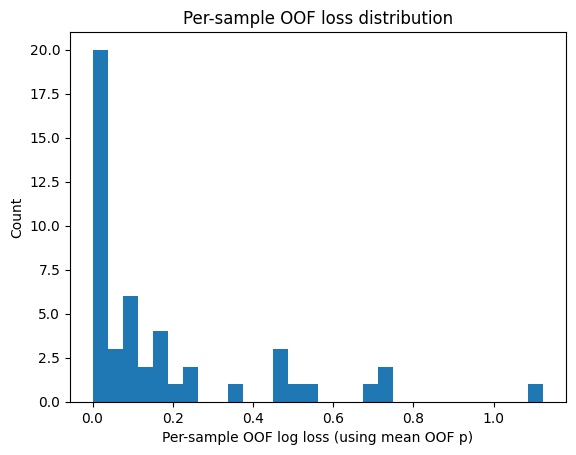

In [54]:
eps = 1e-15
p = np.clip(mean_proba, eps, 1-eps)
mask = ~np.isnan(p)
sample_loss = -(y[mask]*np.log(p[mask]) + (1-y[mask])*np.log(1-p[mask]))

plt.figure()
plt.hist(sample_loss, bins=30)
plt.xlabel("Per-sample OOF log loss (using mean OOF p)")
plt.ylabel("Count")
plt.title("Per-sample OOF loss distribution")
plt.show()


In [55]:
# Attach continuous output back to your dataframe
results = X.copy()
results["y"] = y
results["mean_proba"] = mean_proba       # continuous model score
results["proba_std"] = proba_std        # uncertainty of the score

print(results.head())

Gene               UBIAD1     RPS4Y1     LPAR3   GAL3ST1      PSD2    UQCRHL  \
BSSE_QGF_225167  9.779000  41.153949  0.014408  1.399188  0.044966  1.822870   
BSSE_QGF_225168  8.221273  43.578226  0.186613  1.101547  0.024267  1.790911   
BSSE_QGF_225169  6.799272  40.190190  0.053000  2.018412  0.068921  1.547418   
BSSE_QGF_225170  8.456159  27.801922  0.082806  1.135257  0.010768  1.298356   
BSSE_QGF_225171  7.281019  65.156659  0.359029  2.114036  0.064644  1.747054   

Gene               SLC8A3    CLEC9A      NPFF  C11orf16  ...      NQO1  \
BSSE_QGF_225167  0.189174  0.838118  0.228120  0.332220  ...  4.218423   
BSSE_QGF_225168  0.133994  1.193311  1.149014  0.316390  ...  3.849753   
BSSE_QGF_225169  0.166722  0.371714  1.025624  0.215661  ...  3.217061   
BSSE_QGF_225170  0.067951  0.427024  0.218509  0.149752  ...  8.179920   
BSSE_QGF_225171  0.107650  0.615263  0.000000  0.037459  ...  6.080892   

Gene                 RRM2B    KBTBD3    CDKN2A    GPR160     VARS2     STK

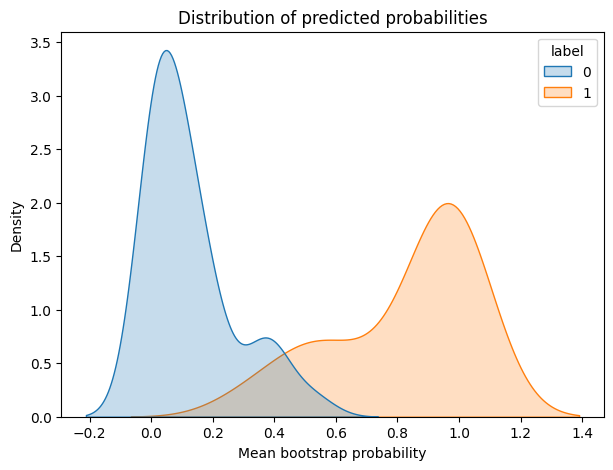

In [56]:
df_plot = pd.DataFrame({
    "mean_proba": mean_proba,
    "label": y
})

plt.figure(figsize=(7,5))
sns.kdeplot(data=df_plot, x="mean_proba", hue="label", fill=True, common_norm=False)
plt.title("Distribution of predicted probabilities")
plt.xlabel("Mean bootstrap probability")
plt.savefig(f'lr_training_proba_histogram_resample_{today}.pdf')
plt.show()

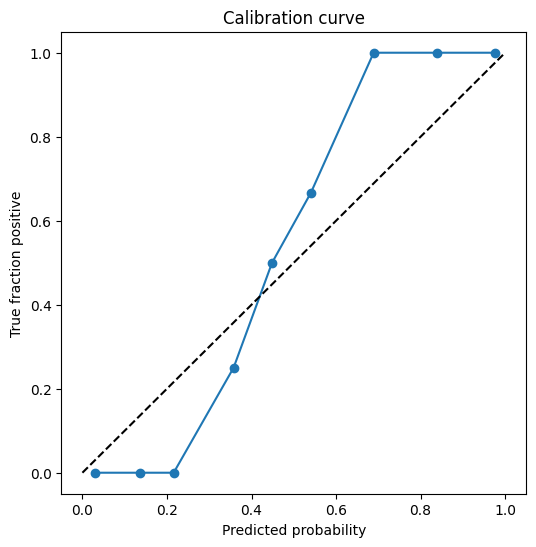

In [57]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y, mean_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "--", color="black")
plt.xlabel("Predicted probability")
plt.ylabel("True fraction positive")
plt.title("Calibration curve")
plt.savefig(f'calibration_curve_full_{today}.pdf')
plt.show()

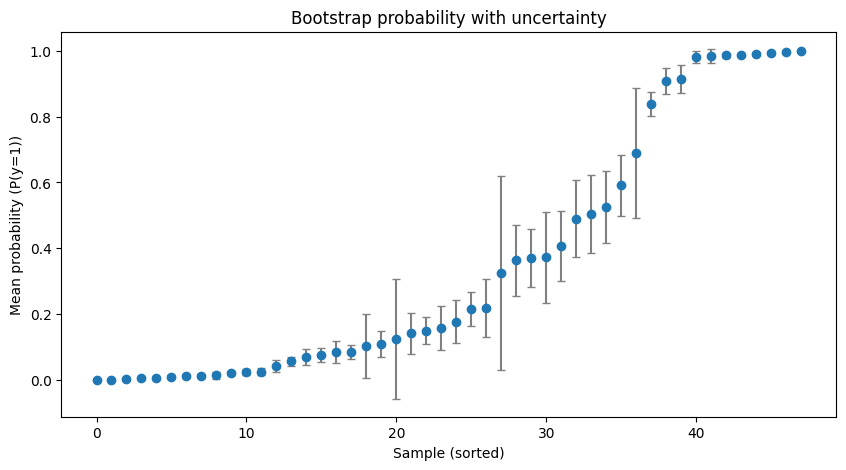

In [58]:
order = np.argsort(mean_proba)  # sort for better visualization

plt.figure(figsize=(10,5))
plt.errorbar(
    x=np.arange(len(mean_proba)),
    y=mean_proba[order],
    yerr=proba_std[order],
    fmt="o",
    ecolor="gray",
    capsize=3
)
plt.title("Bootstrap probability with uncertainty")
plt.ylabel("Mean probability (P(y=1))")
plt.xlabel("Sample (sorted)")
plt.savefig(f'lr_training_proba_bootstrapped_{today}.pdf')
plt.show()

In [59]:
pd.DataFrame(per_sample_probas).shape

(48, 100)

In [60]:
col_colors = y.reset_index().group
col_colors = col_colors.replace(0, 'black')
col_colors = col_colors.replace(1, 'yellow')


<Figure size 1000x600 with 0 Axes>

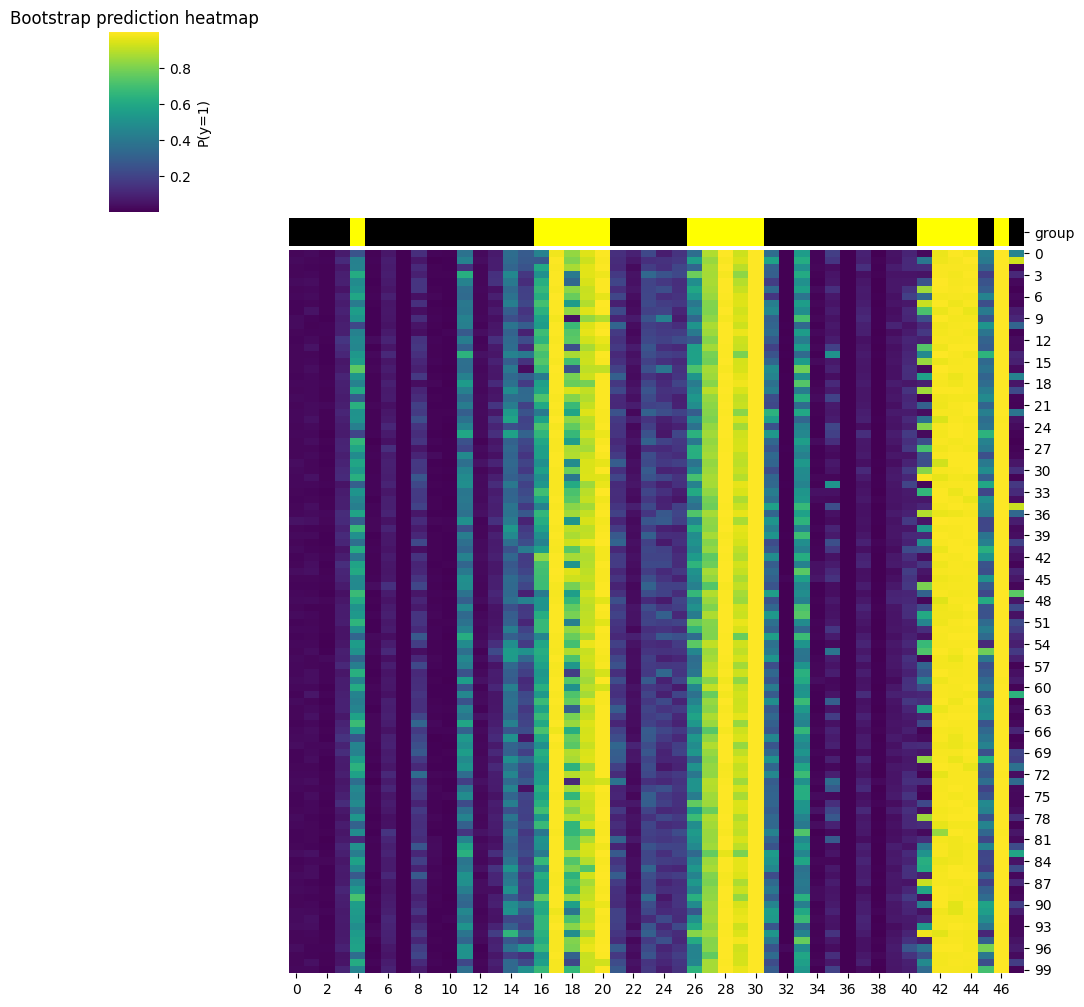

In [61]:
plt.figure(figsize=(10,6))
sns.clustermap(pd.DataFrame(per_sample_probas).T, cmap="viridis", cbar_kws={'label': 'P(y=1)'}, col_colors=col_colors, col_cluster=False, row_cluster=False)
#plt.xlabel("Samples")
#plt.ylabel("Bootstrap iteration")
plt.title("Bootstrap prediction heatmap")
#plt.savefig('heatmap_training_lr.pdf', bbox_inches='tight')
plt.show()

In [62]:
coef_matrix = np.vstack(all_coefs)        # shape: (n_models, n_features)

mean_coef = coef_matrix.mean(axis=0)
std_coef = coef_matrix.std(axis=0)
abs_mean_coef = np.abs(mean_coef)

feature_ranking = (
    pd.DataFrame({
        "feature": model_input.loc[:,top20_features].columns,
        "mean_coef": mean_coef,
        "abs_mean_coef": abs_mean_coef,
        "std_coef": std_coef,
    })
    .sort_values("abs_mean_coef", ascending=True)
)


In [63]:
feature_ranking


,feature,mean_coef,abs_mean_coef,std_coef
5,UQCRHL,0.163628,0.163628,0.111337
17,VARS2,-0.234368,0.234368,0.114412
14,KBTBD3,0.255502,0.255502,0.127901
11,SESN1,0.262184,0.262184,0.162428
13,RRM2B,0.292183,0.292183,0.137169
18,STK38L,0.308134,0.308134,0.091340
10,PLAAT2,0.349951,0.349951,0.163192
16,GPR160,0.377083,0.377083,0.160405
12,NQO1,0.378856,0.378856,0.229926
15,CDKN2A,0.529163,0.529163,0.133987


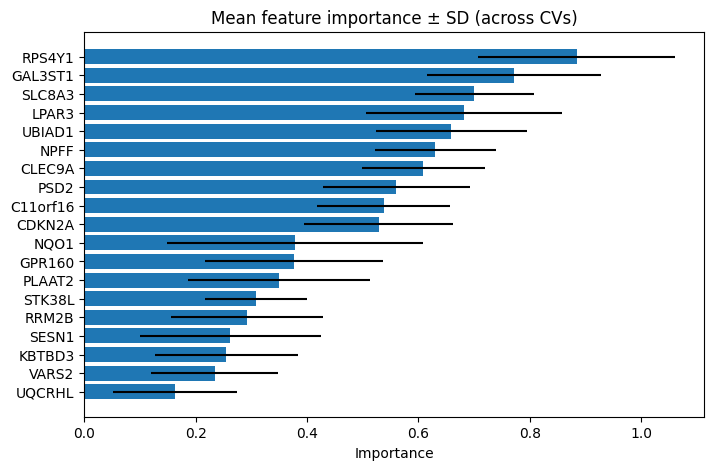

In [64]:
plt.figure(figsize=(8,5))
plt.barh(feature_ranking.feature, feature_ranking.abs_mean_coef, xerr=feature_ranking.std_coef)
plt.xlabel("Importance")
plt.title("Mean feature importance ± SD (across CVs)")
plt.savefig(f'mean_feat_imp_cvs_LR_{today}.pdf')
plt.show()

In [65]:
model_input.loc[:,feature_ranking.sort_values('abs_mean_coef', ascending=False).feature].head()

Gene,RPS4Y1,GAL3ST1,SLC8A3,LPAR3,UBIAD1,NPFF,CLEC9A,PSD2,C11orf16,CDKN2A,NQO1,GPR160,PLAAT2,STK38L,RRM2B,SESN1,KBTBD3,VARS2,UQCRHL
BSSE_QGF_225167,41.153949,1.399188,0.189174,0.014408,9.779000,0.228120,0.838118,0.044966,0.332220,0.498322,4.218423,1.523406,2.001978,10.125537,17.728875,9.382742,1.476580,0.133926,1.822870
BSSE_QGF_225168,43.578226,1.101547,0.133994,0.186613,8.221273,1.149014,1.193311,0.024267,0.316390,0.537854,3.849753,1.606604,2.905898,7.723875,14.667690,9.605612,1.372075,0.170059,1.790911
BSSE_QGF_225169,40.190190,2.018412,0.166722,0.053000,6.799272,1.025624,0.371714,0.068921,0.215661,0.627110,3.217061,1.140741,1.862245,6.544634,13.418677,9.573101,1.258989,0.164216,1.547418
BSSE_QGF_225170,27.801922,1.135257,0.067951,0.082806,8.456159,0.218509,0.427024,0.010768,0.149752,0.464765,8.179920,0.924543,1.454751,6.157810,17.126718,9.805665,1.404999,0.083007,1.298356
BSSE_QGF_225171,65.156659,2.114036,0.107650,0.359029,7.281019,0.000000,0.615263,0.064644,0.037459,1.093444,6.080892,1.482336,0.595462,7.477508,11.937524,7.509406,1.490142,0.120805,1.747054


In [66]:
feature_ranking.to_csv(f'top_19features_{today}.csv')

In [67]:
ss = StandardScaler()
ss.set_output(transform='pandas')

StandardScaler()

In [68]:
df_sel_exp = model_input.loc[:,feature_ranking.sort_values('abs_mean_coef', ascending=False).feature].copy()
df_sel_exp = ss.fit_transform(df_sel_exp)
df_sel_exp['Group'] = y
df_sel_exp = df_sel_exp.melt(id_vars=['Group'], var_name='Gene')
df_sel_exp.Group = df_sel_exp.Group.replace(0, 'CHC_nonHCC')
df_sel_exp.Group = df_sel_exp.Group.replace(1, 'CHC_HCC')
#df_sel_exp = df_sel_exp.T
df_sel_exp.head()

,Group,Gene,value
0,CHC_nonHCC,RPS4Y1,0.387185
1,CHC_nonHCC,RPS4Y1,0.489789
2,CHC_nonHCC,RPS4Y1,0.346395
3,CHC_nonHCC,RPS4Y1,-0.177922
4,CHC_HCC,RPS4Y1,1.403068


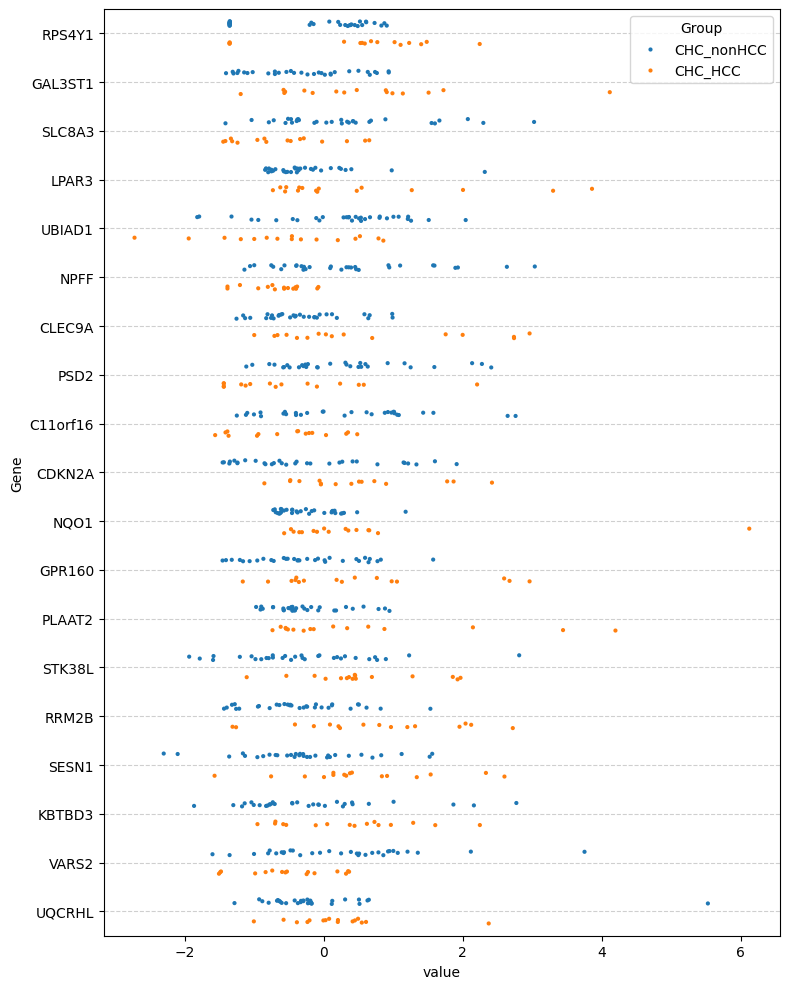

In [69]:
fig, ax = plt.subplots(figsize=(8,10))

#sns.swarmplot(df_sel_exp, x='value', y='Gene_name', hue='Group', dodge=True, size=3)
sns.stripplot(data=df_sel_exp, x='value', y='Gene', hue='Group', dodge=True, jitter=True, size=3, ax=ax, hue_order=['CHC_nonHCC', 'CHC_HCC'])

# Add horizontal gridlines
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Optional: improve layout
plt.tight_layout()
#plt.show()

plt.savefig(f'Swarm_LR_genes_expression_{today}.pdf', dpi=300, bbox_inches='tight')

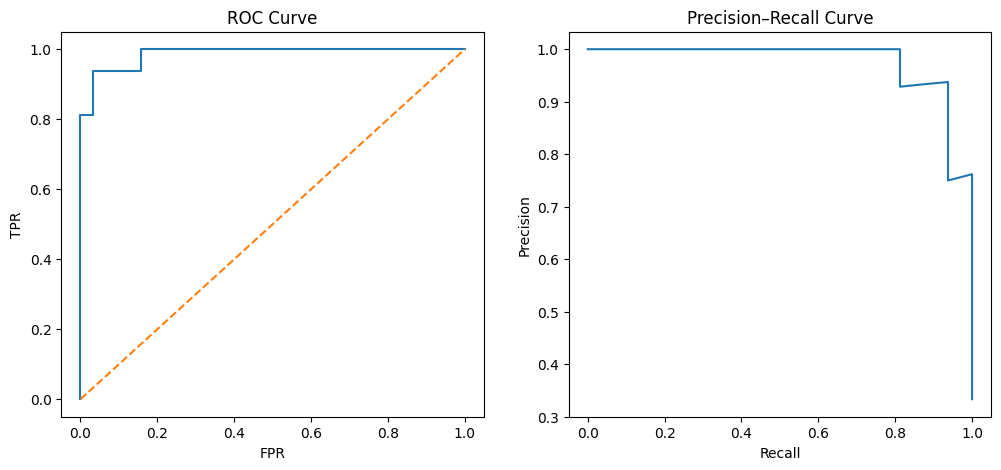

In [70]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y, mean_proba)
prec, rec, _ = precision_recall_curve(y, mean_proba)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(fpr, tpr)
ax[0].plot([0,1],[0,1],'--')
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")

ax[1].plot(rec, prec)
ax[1].set_title("Precision–Recall Curve")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")

plt.savefig(f'LR_roc_prec_training_{today}.pdf', bbox_inches='tight')
plt.show()


# Apply to other HCV samples 

In [ ]:
hcc_hcv_subset_ = hcc_hcv_subset.T.copy()
hcc_hcv_subset_ = hcc_hcv_subset_.loc[:,top20_features]
hcc_hcv_subset_['group'] = 1

In [ ]:
hcv_subset_ = hcv_subset.T.copy()
hcv_subset_ = hcv_subset_.loc[:,top20_features]
hcv_subset_['group'] = 0

In [ ]:
validation_set = pd.concat([hcc_hcv_subset_, hcv_subset_], axis=0)
validation_set.head()

In [ ]:
def predict_bootstrap_proba(models, X_new, scalers):
    X_new = np.asarray(X_new)
    proba_list = []
    for s, m in zip(scalers, models):
        X_scaled = s.transform(X_new)
        p = m.predict_proba(X_scaled)[:, 1]
        proba_list.append(p)
    proba_matrix = np.vstack(proba_list)
    return proba_matrix.mean(axis=0), proba_matrix.std(axis=0)

In [110]:
def compute_feature_contributions(models, scalers, X_new):
    X_new = np.asarray(X_new)

    all_contribs = []

    for s, m in zip(scalers, models):
        X_scaled = s.transform(X_new)  # (n_samples, n_features)
        coefs = m.coef_[0]             # (n_features,)

        contrib = X_scaled * coefs     # broadcast multiply
        all_contribs.append(contrib)

    # shape: (n_models, n_samples, n_features)
    contribs = np.stack(all_contribs, axis=0)

    # Aggregate across ensemble
    mean_contrib = contribs.mean(axis=0)
    std_contrib  = contribs.std(axis=0)

    return mean_contrib, std_contrib

In [111]:
X.shape

(48, 19)

In [112]:
mean_contrib_train, std_contrib_train = compute_feature_contributions(models, scalers, X)

In [115]:
contrib_df_train = pd.DataFrame(
    mean_contrib_train,
    index=model_input.index,
    columns=top20_features
)

contrib_std_df_train = pd.DataFrame(
    std_contrib_train,
    index=model_input.index,
    columns=top20_features
)

meta_contrib_train = pd.DataFrame({
    "sample": model_input.index,
    "label": model_input.group
}).set_index("sample")

In [135]:
# "Validation" cohort

X_new = validation_set.iloc[:,:-1]
y_val = validation_set.group

mean_contrib_new, std_contrib_new = compute_feature_contributions(models, scalers, X_new)

In [137]:
contrib_df_new = pd.DataFrame(
    mean_contrib_new,
    index=validation_set.index,
    columns=validation_set.columns[:-1]
)

contrib_std_df_new = pd.DataFrame(
    std_contrib_new,
    index=validation_set.index,
    columns=validation_set.columns[:-1]
)

meta_contrib_new = pd.DataFrame({
    "sample": validation_set.index,
    "label": validation_set.group
}).set_index("sample")

# Cluster all

In [138]:
contrib_df_all = pd.concat([contrib_df_train, contrib_df_new], axis=0)
contrib_df_all.head()

,UBIAD1,RPS4Y1,LPAR3,GAL3ST1,PSD2,UQCRHL,SLC8A3,CLEC9A,NPFF,C11orf16,PLAAT2,SESN1,NQO1,RRM2B,KBTBD3,CDKN2A,GPR160,VARS2,STK38L
BSSE_QGF_225167,-0.998414,0.342203,-0.577371,-0.056179,0.045070,-0.049719,-0.477987,-0.128844,0.460155,-0.551198,-0.067468,-0.139967,-0.123849,0.031551,-0.187874,-0.395916,-0.135982,0.012297,0.078547
BSSE_QGF_225168,-0.237645,0.433106,-0.128501,-0.366920,0.396466,-0.056879,0.071541,0.357052,-1.232229,-0.476373,0.054070,-0.107547,-0.139408,-0.189766,-0.258354,-0.337982,-0.093789,-0.112573,-0.303580
BSSE_QGF_225169,0.456837,0.306065,-0.476776,0.590302,-0.361581,-0.111431,-0.254389,-0.766875,-1.005468,-0.000255,-0.086256,-0.112277,-0.166110,-0.280067,-0.334620,-0.207179,-0.330044,-0.092383,-0.491209
BSSE_QGF_225170,-0.352360,-0.158461,-0.399085,-0.331726,0.625623,-0.167231,0.729248,-0.691213,0.477819,0.311283,-0.141046,-0.078447,0.043340,-0.011984,-0.236150,-0.445094,-0.439686,0.188264,-0.552756
BSSE_QGF_225171,0.221560,1.242237,0.320920,0.690134,-0.288981,-0.066705,0.333891,-0.433706,0.879387,0.842061,-0.256583,-0.412469,-0.045246,-0.387151,-0.178728,0.476224,-0.156810,0.057639,-0.342780


In [139]:
contrib_std_df_all = pd.concat([contrib_std_df_train, contrib_std_df_new], axis=0)
contrib_std_df_all.head()

,UBIAD1,RPS4Y1,LPAR3,GAL3ST1,PSD2,UQCRHL,SLC8A3,CLEC9A,NPFF,C11orf16,PLAAT2,SESN1,NQO1,RRM2B,KBTBD3,CDKN2A,GPR160,VARS2,STK38L
BSSE_QGF_225167,0.196168,0.087317,0.142054,0.054925,0.038692,0.036642,0.084044,0.046224,0.086948,0.131012,0.038720,0.092475,0.081167,0.022174,0.093144,0.106023,0.066951,0.019014,0.037574
BSSE_QGF_225168,0.051730,0.100597,0.057308,0.086378,0.089094,0.042411,0.048696,0.065412,0.254365,0.115770,0.033393,0.072751,0.092429,0.096888,0.129745,0.092908,0.051278,0.058607,0.091257
BSSE_QGF_225169,0.128564,0.082483,0.121365,0.106074,0.113760,0.089554,0.061795,0.132601,0.211537,0.040026,0.046149,0.075605,0.111884,0.138523,0.169669,0.065197,0.144769,0.049381,0.147659
BSSE_QGF_225170,0.068282,0.070183,0.105727,0.081755,0.142456,0.139307,0.106334,0.121111,0.089896,0.072332,0.069583,0.055476,0.048489,0.023325,0.118170,0.117377,0.189848,0.092393,0.166341
BSSE_QGF_225171,0.082829,0.243908,0.074407,0.120946,0.097013,0.050604,0.063520,0.083253,0.161744,0.179159,0.121753,0.262510,0.027817,0.188274,0.088434,0.123960,0.074999,0.032693,0.102929


In [140]:
meta_contrib_train_ = meta_contrib_train.copy()

meta_contrib_train_.label = meta_contrib_train_.label.replace(0, 'CHC-noHCC')
meta_contrib_train_.label = meta_contrib_train_.label.replace(1, 'CHC-HCC')

In [141]:
meta_contrib_new_ = meta_contrib_new.copy()

meta_contrib_new_.label = meta_contrib_new_.label.replace(0, 'HCV+ HCC-')
meta_contrib_new_.label = meta_contrib_new_.label.replace(1, 'HCV+ HCC+')

In [142]:
meta_contrib_all = pd.concat([meta_contrib_train_, meta_contrib_new_], axis=0)
meta_contrib_all.head()

,label
sample,
BSSE_QGF_225167,CHC-noHCC
BSSE_QGF_225168,CHC-noHCC
BSSE_QGF_225169,CHC-noHCC
BSSE_QGF_225170,CHC-noHCC
BSSE_QGF_225171,CHC-HCC


In [143]:
meta_contrib_all.label.unique()

array(['CHC-noHCC', 'CHC-HCC', 'HCV+ HCC+', 'HCV+ HCC-'], dtype=object)

In [144]:
mean_proba_all = pd.concat([pd.Series(mean_proba, index=X.index),
                            pd.Series(mean_proba_new, index=X_new.index)])
mean_proba_all.head()

BSSE_QGF_225167    0.020949
BSSE_QGF_225168    0.024806
BSSE_QGF_225169    0.009776
BSSE_QGF_225170    0.084434
BSSE_QGF_225171    0.490363
dtype: float64

In [145]:
mean_proba_all = mean_proba_all.sort_values()

In [146]:
# Col colors of mean proba
import matplotlib as mpl

# 1. Normalize values → [0, 1]
norm = mpl.colors.Normalize(vmin=mean_proba_all.min(), vmax=mean_proba_all.max())

# 2. Map to colormap
cmap = mpl.cm.viridis
row_colors = mean_proba_all.map(lambda x: cmap(norm(x)))


In [147]:
row_colors

BSSE_QGF_225206    (0.267004, 0.004874, 0.329415, 1.0)
SRR3898685         (0.267004, 0.004874, 0.329415, 1.0)
BSSE_QGF_225174    (0.267004, 0.004874, 0.329415, 1.0)
SRR3898720         (0.267004, 0.004874, 0.329415, 1.0)
SRR3898679         (0.267004, 0.004874, 0.329415, 1.0)
                                  ...                 
BSSE_QGF_55705     (0.993248, 0.906157, 0.143936, 1.0)
BSSE_QGF_34444     (0.993248, 0.906157, 0.143936, 1.0)
BSSE_QGF_34448     (0.993248, 0.906157, 0.143936, 1.0)
BSSE_QGF_34452     (0.993248, 0.906157, 0.143936, 1.0)
BSSE_QGF_35701     (0.993248, 0.906157, 0.143936, 1.0)
Length: 91, dtype: object

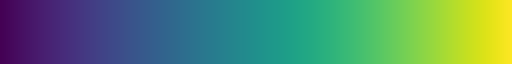

In [148]:
cmap

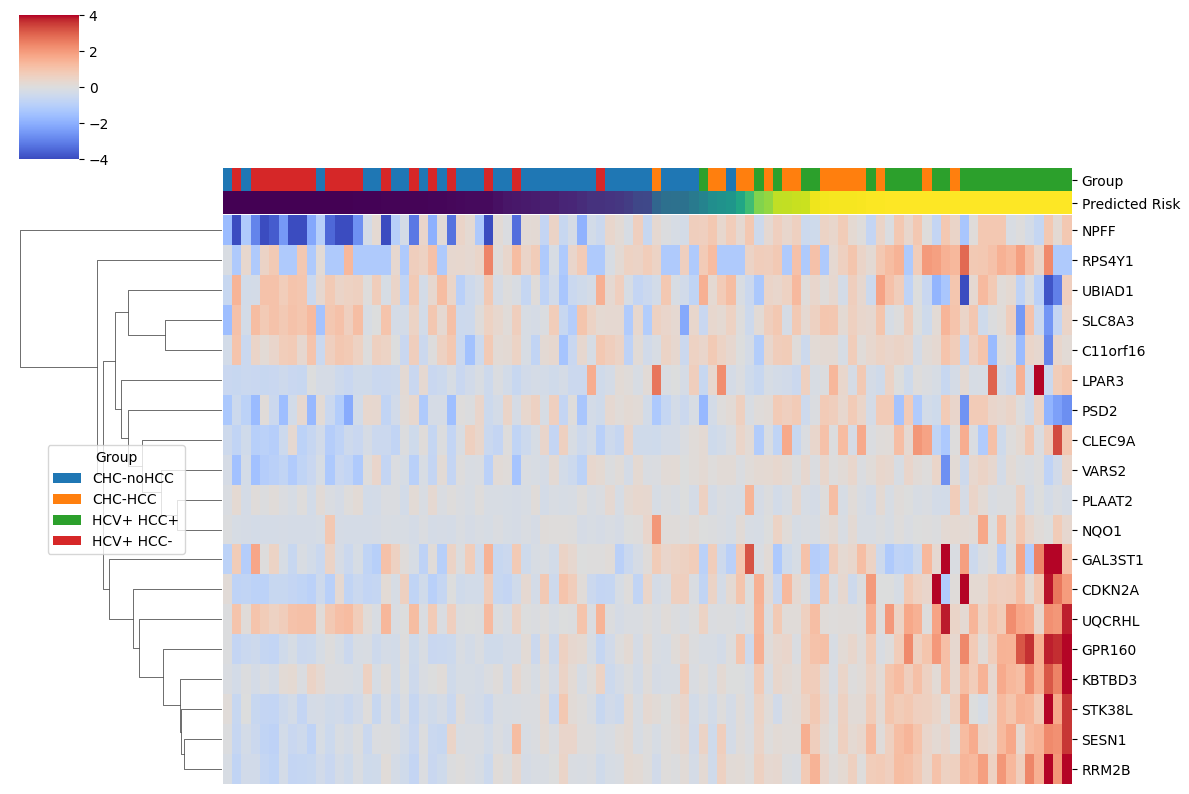

In [149]:
plot_df = contrib_df_all.T.copy()
plot_df = plot_df.loc[:,mean_proba_all.index]

# color map for the 7 labels
unique_labels = meta_contrib_all.label.unique()
palette = sns.color_palette("tab10", n_colors=len(unique_labels))
lut = dict(zip(unique_labels, palette))
group = meta_contrib_all.loc[plot_df.columns, "label"].map(lut)

proba = row_colors.loc[plot_df.columns]

col_colors = pd.concat([group, proba], keys=['Group', 'Predicted Risk'], axis=1)

g = sns.clustermap(
    plot_df,
    cmap="coolwarm",
    center=0,
    col_colors=col_colors,
    col_cluster=False,
    row_cluster=True,   # set False if you want original sample order
    figsize=(12, 8),
    vmin=-4,
    vmax=4,
    xticklabels=False,
    yticklabels=True
)

# legend for row colors
for label, color in lut.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
g.ax_row_dendrogram.legend(title="Group", loc="center", ncol=1)

plt.savefig(f'clustermap_applied_score_{today}.pdf', dpi=300, bbox_inches='tight')
plt.show()